<a href="https://colab.research.google.com/github/MinhKiet05/NMLTPTDL1/blob/main/on-thi-GK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('sales_data_sample.xlsx', sheet_name = "saledata")
df.head(5)

,ORDERNUMBER,QUANTITYORDERED,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,COUNTRY,DEALSIZE,Discount,Profit
0,10107,30,2,2871.00,2003-02-24,Shipped,USA,Small,0.00,41.9136
1,10121,34,5,2765.90,2003-05-07,Shipped,France,Small,0.00,219.5820
2,10134,41,2,3884.34,2003-07-01,Shipped,France,Medium,0.00,6.8714
3,10145,45,6,3746.70,2003-08-25,Shipped,USA,Medium,0.45,-383.0310
4,10159,49,14,5205.27,2003-10-10,Shipped,USA,Medium,0.20,2.5164


In [ ]:
#th01-02: Hãy cho biết kích thước của dữ liệu
df.shape

(2823, 10)

In [ ]:
#th01-11: Hãy cho biết hóa đơn 10107 có bao nhiêu dòng sản phẩm

df[df['ORDERNUMBER']==10107]
# hoặc df.loc[df['ORDERNUMBER']==10107]

,ORDERNUMBER,QUANTITYORDERED,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,COUNTRY,DEALSIZE,Discount,Profit
0,10107,30,2,2871.00,2003-02-24,Shipped,USA,Small,0.0,41.9136
54,10107,39,5,3896.49,2003-02-24,Shipped,USA,Medium,0.0,298.6855
80,10107,27,4,6065.55,2003-02-24,Shipped,USA,Medium,0.0,8.0352
240,10107,21,1,3036.60,2003-02-24,Shipped,USA,Medium,0.2,11.1944
804,10107,29,6,2055.23,2003-02-24,Shipped,USA,Small,0.0,6.2152
1466,10107,25,3,2845.75,2003-02-24,Shipped,USA,Small,0.2,-10.7973
1564,10107,38,7,3155.14,2003-02-24,Shipped,USA,Medium,0.0,17.7450
2173,10107,20,8,1858.00,2003-02-24,Shipped,USA,Small,0.8,-13.8960


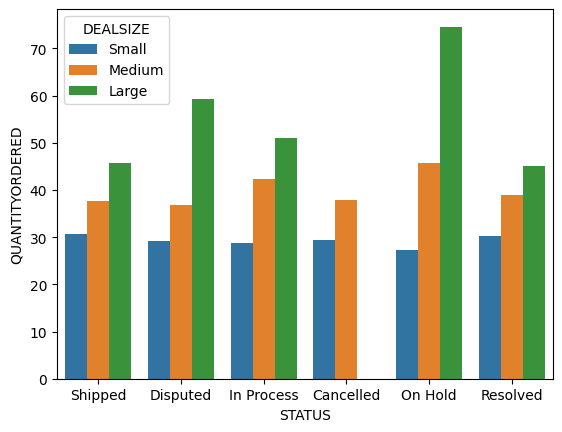

In [ ]:
#th01-10: Hãy cho biết biểu đồ thể hiện trung bình số lượng sản phẩm trên từng nhóm DEALSIZE và STATUS.
#Thì nhóm status nào chỉ có 2 cột thuốc nhóm status nào
sns.barplot(x='STATUS', y='QUANTITYORDERED',
            hue='DEALSIZE', data=df, errorbar=None)
plt.show()

In [ ]:
#th01-17: Có mối liên hệ giữa trạng thái giao hàng(STATUS) và giá trị đặt hàng(SALE) hay không
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('SALES ~ STATUS', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=1)
aov_table

,df,sum_sq,mean_sq,F,PR(>F)
STATUS,5.0,5.921801e+07,1.184360e+07,3.506652,0.003661
Residual,2817.0,9.514324e+09,3.377467e+06,NaN,NaN


In [ ]:
#Ans: Có phụ thuộc

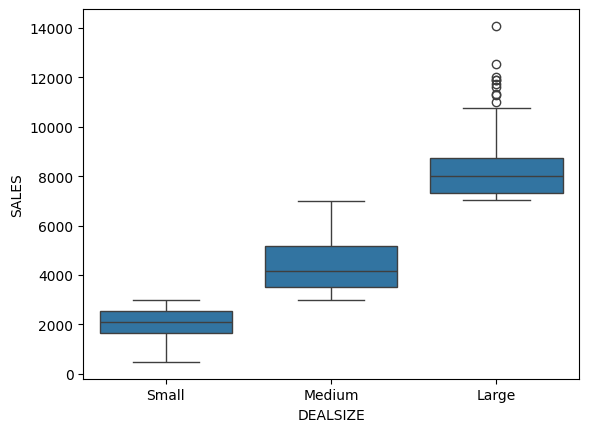

In [ ]:
#th01-22: Hãy cho biết dựa vào biểu đồ boxplot về doanh số trên từng nhóm kích thước đặt hàng thì yếu tố về kích thước đặt hàng có vai trò trong việc dự báo giá trị đặt hàng hay không
sns.boxplot(x='DEALSIZE', y='SALES', data=df)
plt.show()

In [ ]:
#Ans: Có

In [ ]:
#th01-23: Hãy cho biết dựa vào biểu đồ boxplot về doanh số trên từng nhóm kích thước đặt hàng, nếu có dữ liệu thiếu trên nhóm DEALSIZE = Medium thì dữ liệu thiếu đó nên được thay thế bằng
#(vẽ lại đồ thị ở trên)
#a. Trung bình SALES của nhóm Small
#b. Trung bình SALES của nhóm Large
#c. Trung bình SALES của nhóm Medium
#d. Trung vị của giá trị SALES
#e. Trung bình giá trị SALES của nhóm Small và Medium
#f. Trung bình giá trị SALES của nhóm Large và Medium

#Ans: c

In [ ]:
#th01-31: Nếu sử dụng One Hot Encoding để số hóa dữ liệu DEALSIZE thì kết quả của dòng cuối cùng là bao nhiêu
# Encoding to vectorize
from sklearn.preprocessing import OneHotEncoder
y = OneHotEncoder().fit_transform(df[['DEALSIZE']]).toarray()
print(y)

[[0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [ ]:
#th01-32: Nếu sử dụng Max Absolute Scaler cho SALES thì giá trị có index = 100 được scale thành bao nhiêu
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
scaler.fit(df[['SALES']])
scaled = scaler.transform(df[['SALES']])
scaled_df = pd.DataFrame(scaled, columns=df[["SALES"]].columns)


print(scaled_df.iloc[100])

#Ans: 0.212325

SALES    0.212325
Name: 100, dtype: float64


In [ ]:
#th01-38: Hãy sắp xếp giảm dần theo cho mức độ lệch của SALES sau khi được transform lần lượt qua hàm log, sqrt, square và cube root

#a. square, chưa transform, sqrt, cube root, log
#b. chưa transform, sqrt, cube root, log, square
#c. square, chưa transform, cube root, log, sqrt
#d. sqrt, cube root, log, square, chưa transform

import numpy as np

print(df['SALES'].skew())
print(np.log(df['SALES']).skew())
print(np.sqrt(df['SALES']).skew())
print(np.square(df['SALES']).skew())
print(np.cbrt(df['SALES']).skew())

#ans: a vì lấy trị tuyệt đối của các giá trị

1.161076000881289
-0.2021742362869817
0.47281500087876144
2.915766495908139
0.25086487312083483


0.7679976616615047


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

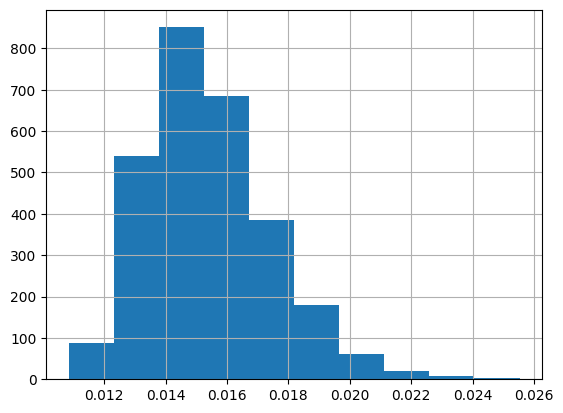

In [ ]:
#th01-39: Hãy tìm giá trị lệch của SALES sau khi được transform qua hàm f(x)=1/(log(x)^2+1)

def fx(x):
  return 1/(np.log(x)**2 + 1)

sales_trans = fx(df['SALES'])
print(sales_trans.skew())
sales_trans.hist()
plt.plot